In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define h
K = 10
h = np.zeros([K])

# Set initial values for h
h[0] = 1

# Define recurrent connection
w    = 2

# Simulate the model
for k in np.arange(K-1):

    # Compute the activity at the next step.
    h[k+1] = w*h[k]

# f = plt.figure()
# plt.plot(h)
# plt.xlabel('Time')
# plt.ylabel('activity');

In [ ]:
# The network has 3 inputs (
# I = [1,3,-3]), 3 hidden nodes, and 3 outputs.

# Set all bias = 0
I = np.array([1,3,-3]).reshape((3,1))
W = np.random.randint(0,3, size=(3,3))
W2 = np.random.randint(0,3, size=(3,3))
h = np.zeros((3,1))

h = W @ I
H = np.where(h>0, 1, 0); print(f'H = {H}\n')
y = W2 @ H; print('y = ', y)
Y = np.where(y>0, 1, 0); print(f'\nY = {Y}')

H = [[0]
 [1]
 [1]]

y =  [[4]
 [1]
 [2]]

Y = [[1]
 [1]
 [1]]


In [ ]:
!pip install graphviz

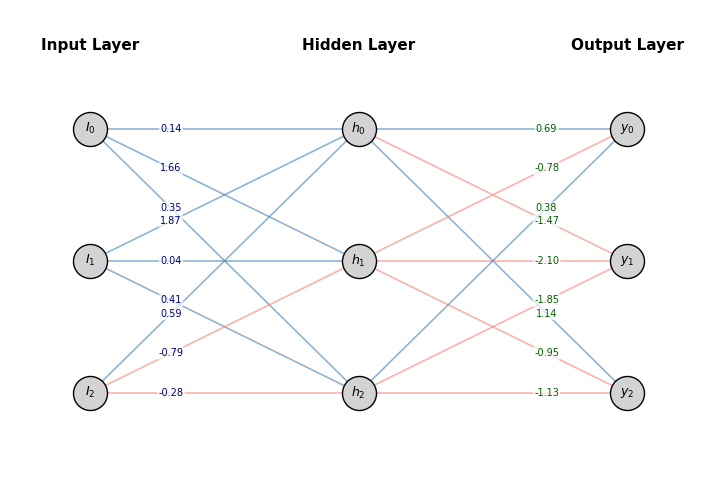

In [ ]:
from graphviz import Digraph

dot = Digraph(format='png')
dot.attr(rankdir='LR')

# Add input nodes
for i in range(3):
    dot.node(f'I{i}', f'I_{i}')

# Add hidden nodes
for h in range(3):
    dot.node(f'h{h}', f'h_{h}')

# Add output nodes
for y in range(3):
    dot.node(f'y{y}', f'y_{y}')

# Connect inputs to hidden
for i in range(3):
    for h in range(3):
        dot.edge(f'I{i}', f'h{h}')

# Connect hidden to outputs
for h in range(3):
    for y in range(3):
        dot.edge(f'h{h}', f'y{y}')

import numpy as np
import matplotlib.pyplot as plt

# Define layers and random weights (round to 2 decimals for clean display)
W_hidden = np.random.randn(3, 3)
W_out = np.random.randn(3, 3)

# Coordinates for each layer
layer_x = {'Input': 0, 'Hidden': 2, 'Output': 4}
y_positions = [1, 0, -1]  # 3 nodes per layer

fig, ax = plt.subplots(figsize=(9, 6))

# 1. Draw connections and weights: Input -> Hidden
for i in range(3):        # input index
    for j in range(3):    # hidden index
        x_start, y_start = layer_x['Input'], y_positions[i]
        x_end, y_end = layer_x['Hidden'], y_positions[j]

        # Draw line (color indicates sign: blue for positive, red for negative)
        weight = W_hidden[j, i]
        color = 'steelblue' if weight >= 0 else 'salmon'
        ax.plot([x_start, x_end], [y_start, y_end], color=color, alpha=0.6, lw=1.2)

        # Label weight near the first third of the line
        xt = x_start + 0.3 * (x_end - x_start)
        yt = y_start + 0.3 * (y_end - y_start)
        ax.text(xt, yt, f'{weight:.2f}', fontsize=7, color='navy',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.7))

# 2. Draw connections and weights: Hidden -> Output
for j in range(3):        # hidden index
    for k in range(3):    # output index
        x_start, y_start = layer_x['Hidden'], y_positions[j]
        x_end, y_end = layer_x['Output'], y_positions[k]

        weight = W_out[k, j]
        color = 'steelblue' if weight >= 0 else 'salmon'
        ax.plot([x_start, x_end], [y_start, y_end], color=color, alpha=0.6, lw=1.2)

        # Label weight near the second third of the line
        xt = x_start + 0.7 * (x_end - x_start)
        yt = y_start + 0.7 * (y_end - y_start)
        ax.text(xt, yt, f'{weight:.2f}', fontsize=7, color='darkgreen',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.7))

# 3. Draw Nodes and Labels
node_labels = {
    'Input': [r'$I_0$', r'$I_1$', r'$I_2$'],
    'Hidden': [r'$h_0$', r'$h_1$', r'$h_2$'],
    'Output': [r'$y_0$', r'$y_1$', r'$y_2$']
}

for layer, x in layer_x.items():
    for idx, y in enumerate(y_positions):
        # Draw node circle
        ax.scatter(x, y, s=600, color='lightgray', edgecolor='black', zorder=5)
        # Node label inside
        ax.text(x, y, node_labels[layer][idx], fontsize=9, fontweight='bold',
                ha='center', va='center', zorder=6)

# Title and formatting
ax.text(layer_x['Input'], 1.6, 'Input Layer', ha='center', fontsize=11, fontweight='bold')
ax.text(layer_x['Hidden'], 1.6, 'Hidden Layer', ha='center', fontsize=11, fontweight='bold')
ax.text(layer_x['Output'], 1.6, 'Output Layer', ha='center', fontsize=11, fontweight='bold')

ax.set_xlim(-0.6, 4.6)
ax.set_ylim(-1.6, 1.9)
ax.axis('off')

plt.show()


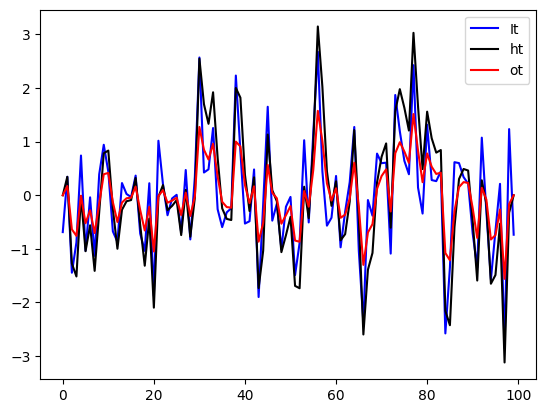

In [ ]:
# one node simulation

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    S = 1 / (1+np.exp(-x))
    return S

K  = 100
It = np.random.randn(K);
ht = np.zeros([K,1])
ot = np.zeros([K,1])

# Initial state
ht[0] = 0.0
ot[0] = 0.0

# Set parameters
Wih = 1
Whh = 0.5
Who = 0.5

# Compute the activity at the next step.



# Update h and o at each time.
for k in np.arange(1,K-1):

    ht[k] = Wih * It[k] + Whh * ht[k-1]
    H = sigmoid(ht[k])
    ot[k] = Who * ht[k]
    O = sigmoid(ot[k])


plt.plot(It, 'b')
plt.plot(ht, 'k')
plt.plot(ot, 'r')
plt.legend(['It', 'ht', 'ot'])

# Challenge Problems

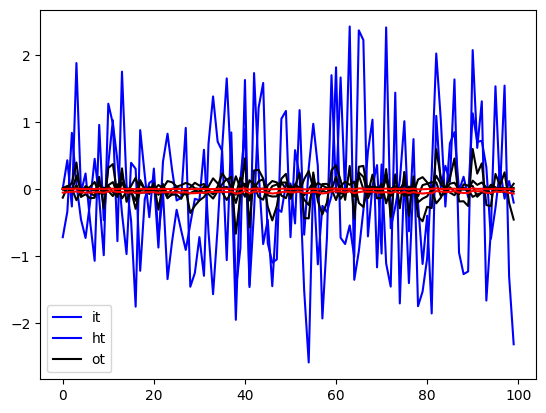

In [ ]:
'''Simulate a traditional RNN with 2 input nodes, 4 hidden nodes, and 2 output nodes. See, for example, slides 20-23 from the lecture.
You will need to make parameter choices, such as the connectivity matrices (
,
,
), the bias values, the activation function
, etc. For input, make
 a one-dimensional vector of random noise (normally distributed).
 Note that the challenge is only to simulate the feedforward solution (not to train the network with backpropagation; that’s a bigger challenge)'''
def sigmoid(x):
  return 1/(1+np.exp(-x))

K = 100
ht = np.zeros([K,4])
ot = np.zeros([K,2])
it = np.random.randn(K,2)

Wih = 0.1 * np.random.randn(4, 2)
Whh = 0.1 * np.random.randn(4, 4)
Who = 0.1 * np.random.randn(2, 4)

for k in range(K):
  ht[k] = Wih @ it[k] + Whh @ ht[k-1] # 100x4 to a 4x1 = 4x2 x 2x1 + 4x4 x 4x1 + 4x1
  H = sigmoid(ht[k]) #np.tanh(ht[k])
  ot[k] = Who @ H # 2x4 x 4x1 = 2x1
  O = sigmoid(ht[k])# np.tanh(ot[k]) # 2x1

plt.plot(it, 'b')
plt.plot(ht, 'k')
plt.plot(ot, 'r')
plt.legend(['it', 'ht', 'ot'])

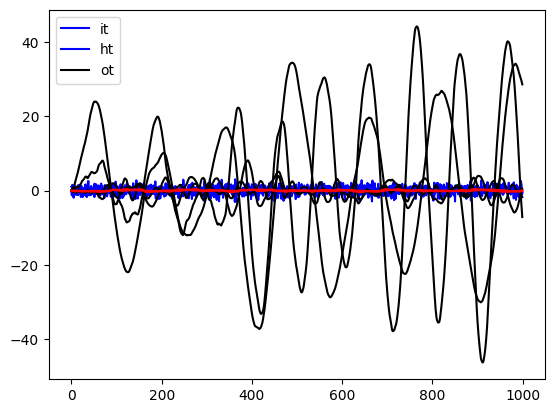

In [ ]:
K = 1000
ht = np.zeros([K,4])
ot = np.zeros([K,2])
it = np.random.randn(K,2)

#hparams
dt = 0.001
beta = 1.0
freqs = np.array([6.18, 10.0, 16.18, 26.18])
omega = 2 * np.pi * freqs

# w1,j = weight for node j at time lag 1
w1 = (2 * (1+beta*dt))/(1+(2*beta*dt+omega**2*dt**2)) # list
w2 = -1 / (1+(2*beta*dt+omega**2*dt**2)) # list

#
Wih = 0.1 * np.random.randn(4, 2)
Whh1 = np.diag(w1)
Whh2 = np.diag(w2)
Who = 0.1 * np.random.randn(2, 4)

for k in range(K):
  ht[k] = Wih @ it[k] + Whh1 @ ht[k-1] + Whh2 @ ht[k-2] # 100x4 to a 4x1 = 4x2 x 2x1 + 4x4 x 4x1 + 4x1
  H = np.tanh(ht[k])
  ot[k] = Who @ H # 2x4 x 4x1 = 2x1
  O = np.tanh(ot[k]) # 2x1

plt.plot(it, 'b')
plt.plot(ht, 'k')
plt.plot(ot, 'r')
plt.legend(['it', 'ht', 'ot'])

Text(0, 0.5, 'Activity')

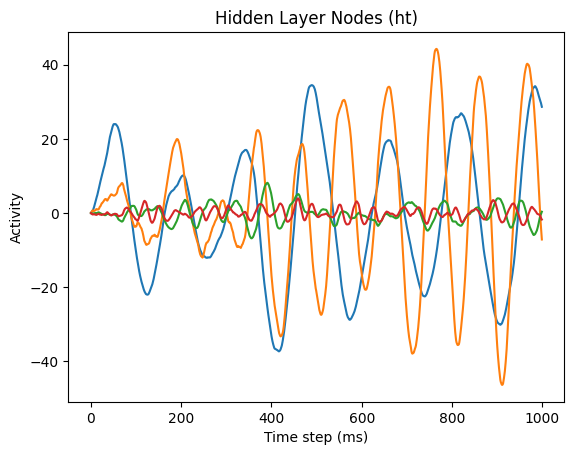

In [ ]:
plt.figure()
plt.plot(ht[:1000])
plt.title("Hidden Layer Nodes (ht)")
plt.xlabel("Time step (ms)")
plt.ylabel("Activity")


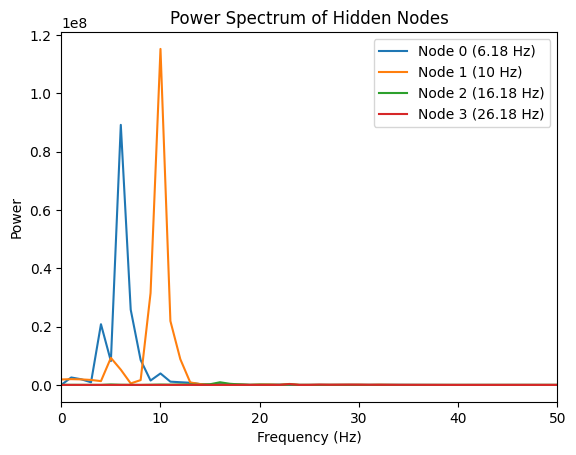

In [ ]:
# Compute FFT and power along the time axis (axis 0)
fft_vals = np.fft.rfft(ht, axis=0)
power = np.abs(fft_vals)**2
freq_axis = np.fft.rfftfreq(K, d=dt)

# Plot power spectrum up to 50 Hz
plt.figure()
plt.plot(freq_axis, power)
plt.xlim(0, 50)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectrum of Hidden Nodes")
plt.legend(['Node 0 (6.18 Hz)', 'Node 1 (10 Hz)', 'Node 2 (16.18 Hz)', 'Node 3 (26.18 Hz)'])
plt.show()
